# Healthcare Patient Analytics & Risk Analysis System

## Day 8 — Multivariate Analysis

### Objective
Analyze relationships between three or more variables to identify
deeper patterns in patient risk, healthcare costs, disease,
readmission, and length of stay.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# load dataset
df = pd.read_csv("/content/cleaned_healthcare_patients.csv")

# veify dataset
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape: (10000, 16)
Missing values: 0
Duplicate rows: 0


## What is Multivariate Analysis?

Multivariate analysis examines three or more variables together.

Unlike bivariate analysis, which studies relationships between two
variables, multivariate analysis helps us understand how multiple
factors interact with an outcome.

In this project, we will analyze combinations such as:

- Age + Disease + Risk Score
- Disease + Admission Type + Length of Stay
- Disease + Smoking Status + Risk Score
- Age + Risk Score + Treatment Cost
- Disease + Readmission + Risk Score
- Admission Type + Disease + Treatment Cost

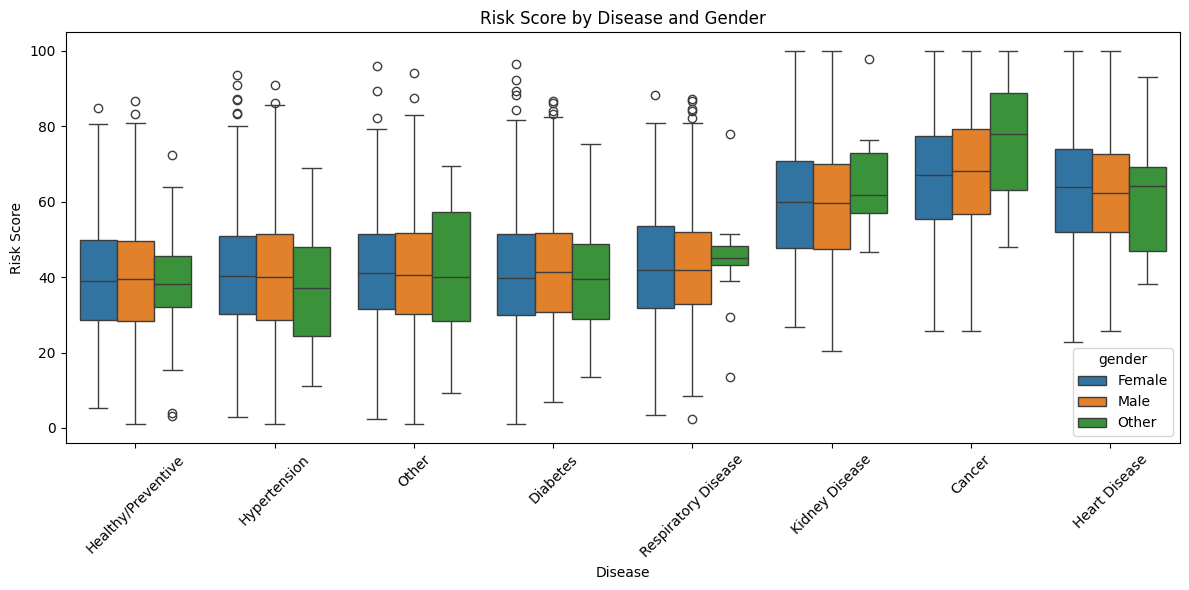

In [5]:
# Age + Disease + Risk Score
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="disease",
    y="risk_score",
    hue="gender"
)

plt.title("Risk Score by Disease and Gender")
plt.xlabel("Disease")
plt.ylabel("Risk Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

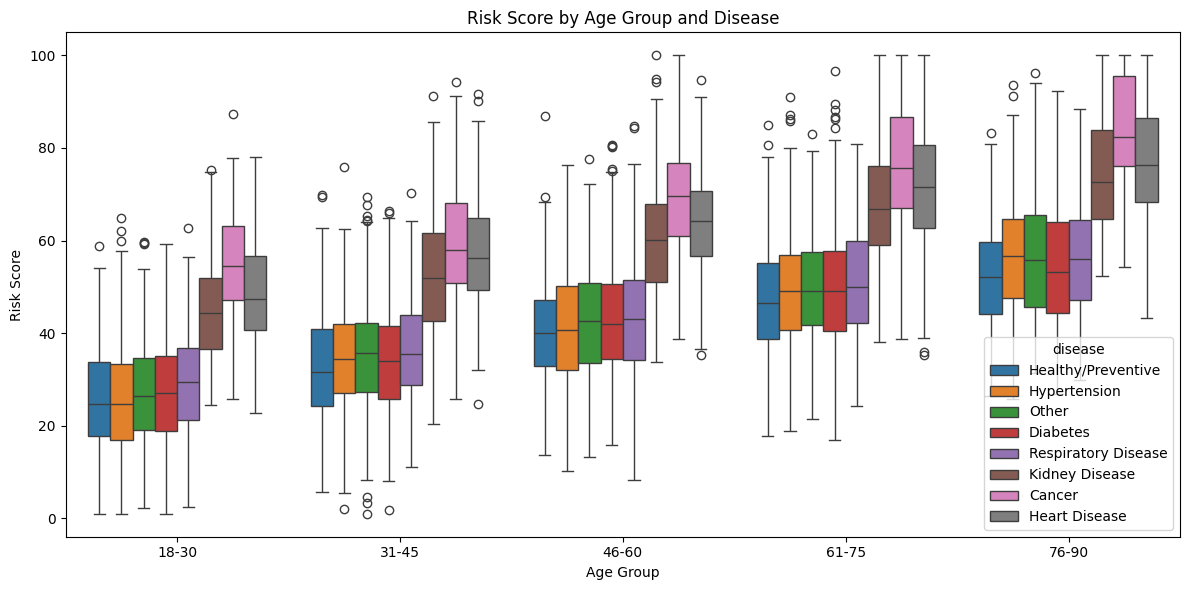

In [9]:
# Disease + Age Group + Risk Score
age_bins = [17, 30, 45, 60, 75, 90]

age_labels = [
    "18-30",
    "31-45",
    "46-60",
    "61-75",
    "76-90"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels
)
df["age_group"].value_counts().sort_index()


plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="age_group",
    y="risk_score",
    hue="disease"
)

plt.title("Risk Score by Age Group and Disease")
plt.xlabel("Age Group")
plt.ylabel("Risk Score")

plt.tight_layout()
plt.show()

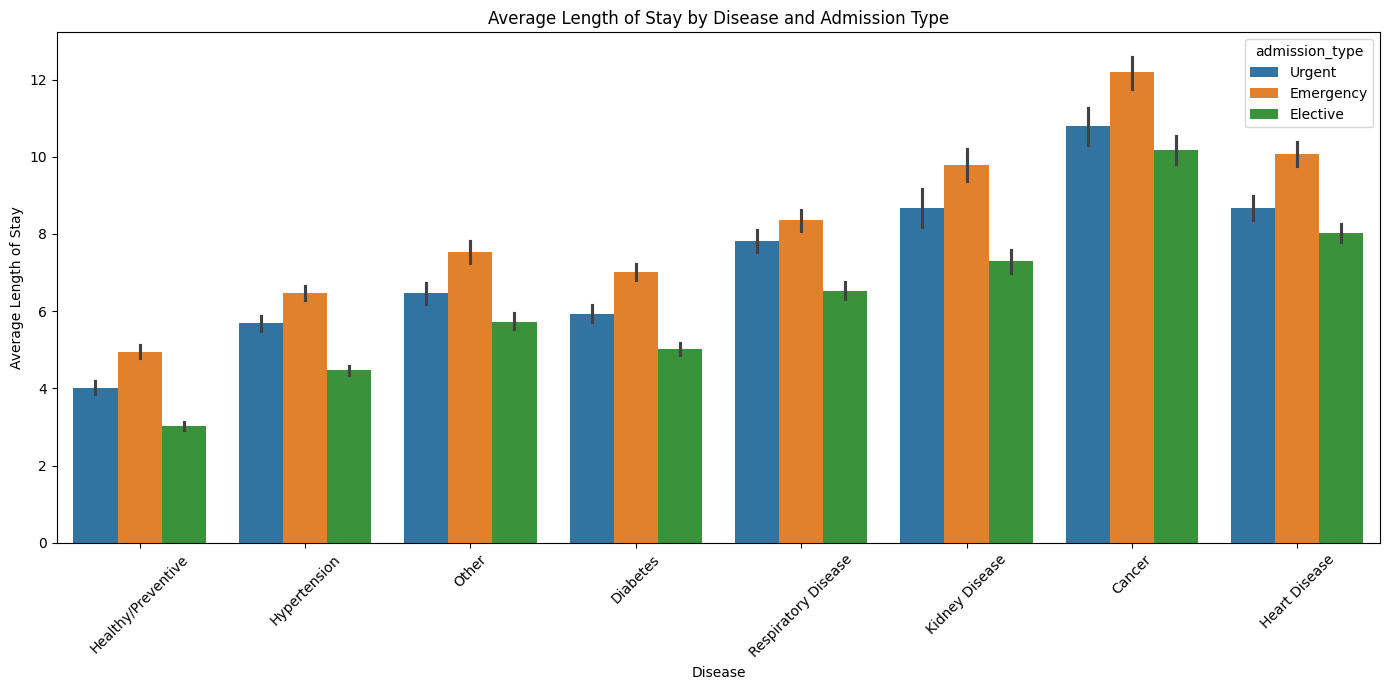

In [11]:
# Disease + Admission Type + Length of Stay
stay_summary = (
    df.groupby(["disease", "admission_type"])["length_of_stay"]
      .agg(["count", "mean", "median"])
      .round(2)
)

stay_summary

plt.figure(figsize=(14, 7))

sns.barplot(
    data=df,
    x="disease",
    y="length_of_stay",
    hue="admission_type"
)

plt.title("Average Length of Stay by Disease and Admission Type")
plt.xlabel("Disease")
plt.ylabel("Average Length of Stay")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

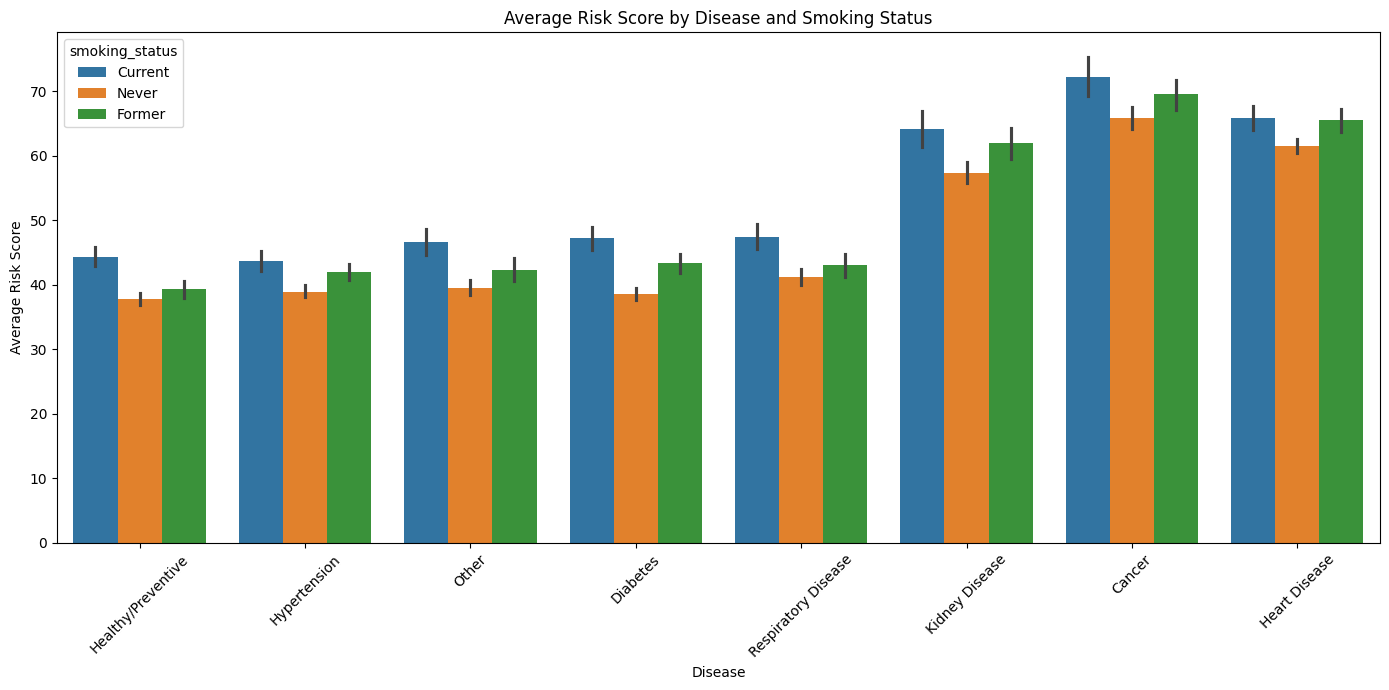

In [12]:
# Disease + Smoking + Risk Score
smoking_risk = (
    df.groupby(["disease", "smoking_status"])["risk_score"]
      .agg(["count", "mean", "median"])
      .round(2)
)

smoking_risk

plt.figure(figsize=(14, 7))

sns.barplot(
    data=df,
    x="disease",
    y="risk_score",
    hue="smoking_status"
)

plt.title("Average Risk Score by Disease and Smoking Status")
plt.xlabel("Disease")
plt.ylabel("Average Risk Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

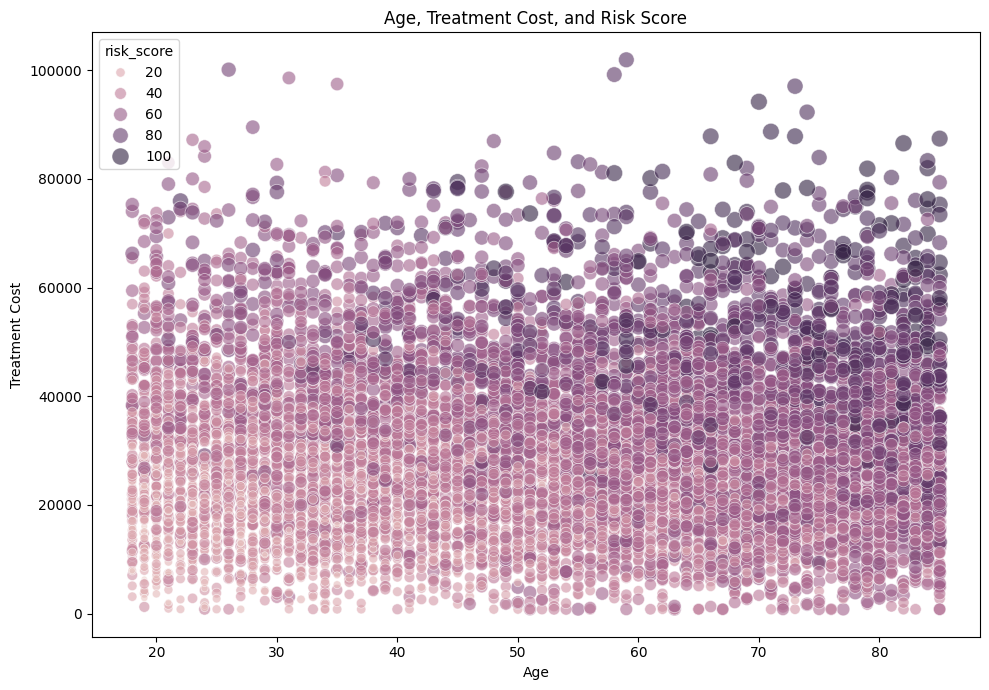

In [13]:
# Age + Risk Score + Treatment Cost
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="age",
    y="treatment_cost",
    hue="risk_score",
    size="risk_score",
    sizes=(20, 150),
    alpha=0.6
)

plt.title("Age, Treatment Cost, and Risk Score")
plt.xlabel("Age")
plt.ylabel("Treatment Cost")

plt.tight_layout()
plt.show()

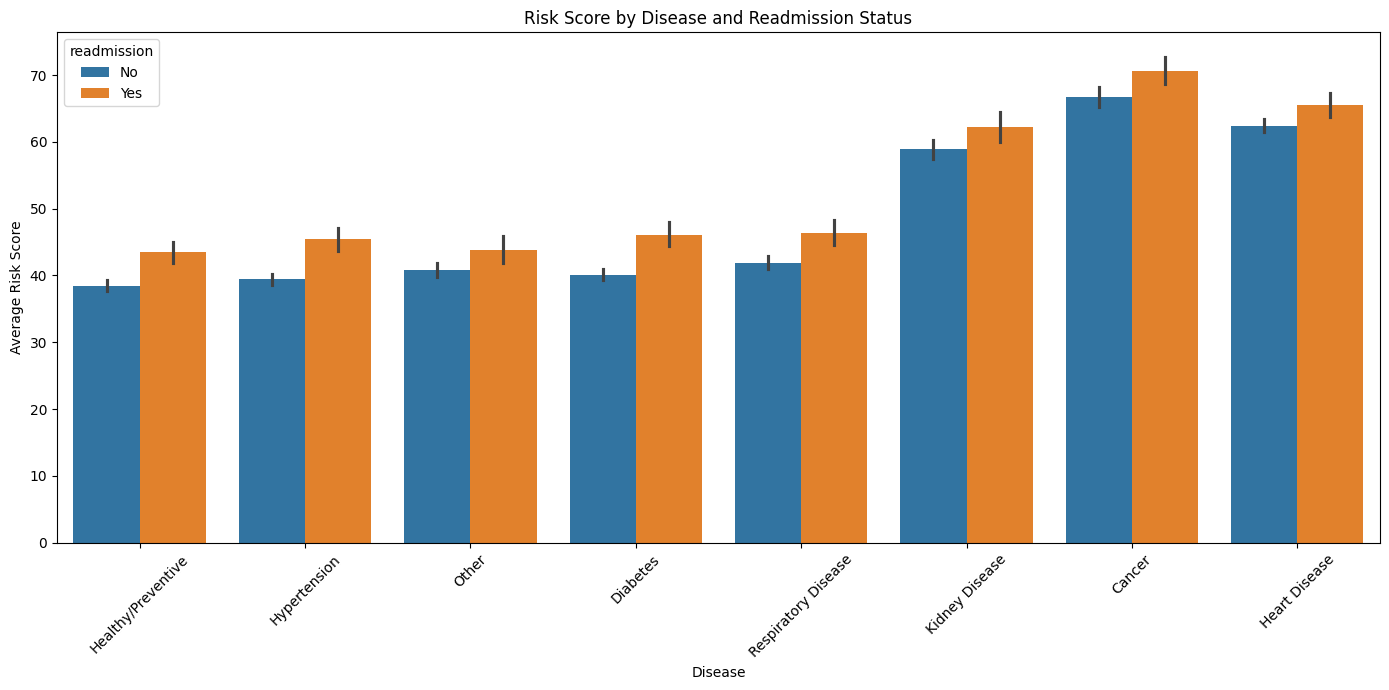

In [15]:
# Disease + Readmission + Risk Score
readmission_risk = (
    df.groupby(["disease", "readmission"])["risk_score"]
      .agg(["count", "mean", "median"])
      .round(2)
)

readmission_risk

plt.figure(figsize=(14, 7))

sns.barplot(
    data=df,
    x="disease",
    y="risk_score",
    hue="readmission"
)

plt.title("Risk Score by Disease and Readmission Status")
plt.xlabel("Disease")
plt.ylabel("Average Risk Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

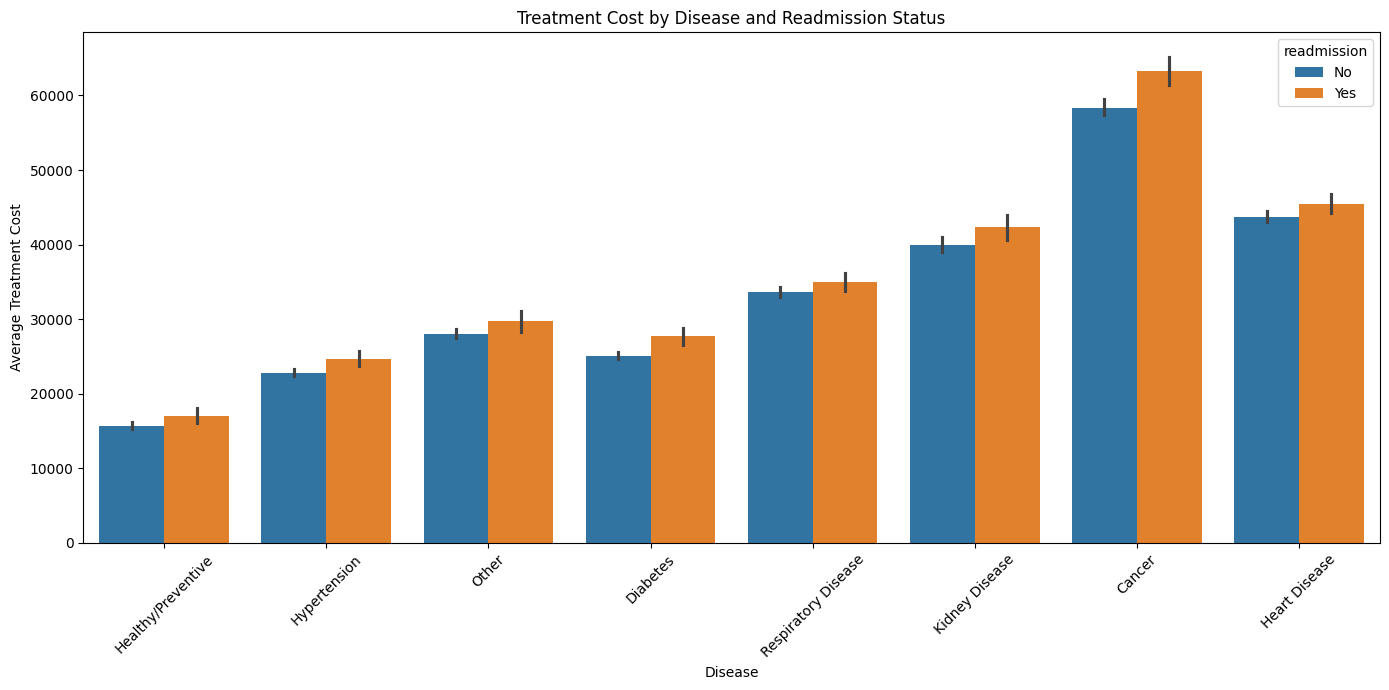

In [16]:
# Disease + Readmission + Treatment Cost
cost_readmission = (
    df.groupby(["disease", "readmission"])["treatment_cost"]
      .agg(["count", "mean", "median"])
      .round(2)
)

cost_readmission

plt.figure(figsize=(14, 7))

sns.barplot(
    data=df,
    x="disease",
    y="treatment_cost",
    hue="readmission"
)

plt.title("Treatment Cost by Disease and Readmission Status")
plt.xlabel("Disease")
plt.ylabel("Average Treatment Cost")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

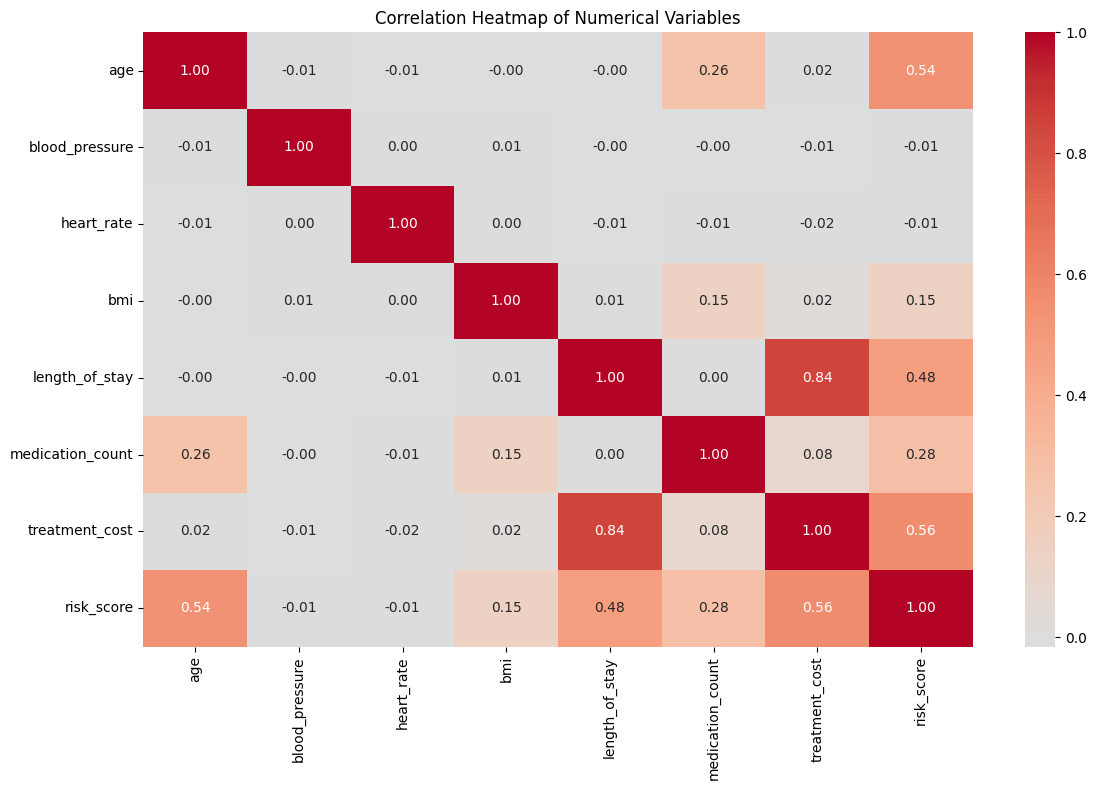

In [18]:
# Correlation Heatmap
numerical_columns = [
    "age",
    "blood_pressure",
    "heart_rate",
    "bmi",
    "length_of_stay",
    "medication_count",
    "treatment_cost",
    "risk_score"
]

correlation_matrix = df[numerical_columns].corr()

correlation_matrix.round(2)

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

In [20]:
# Find the strongest correlations
correlation_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

correlation_pairs

length_of_stay    treatment_cost      0.841815
treatment_cost    risk_score          0.556546
age               risk_score          0.537061
length_of_stay    risk_score          0.475166
medication_count  risk_score          0.276955
age               medication_count    0.258895
bmi               risk_score          0.149893
                  medication_count    0.146097
medication_count  treatment_cost      0.082722
bmi               treatment_cost      0.016495
age               treatment_cost      0.015820
heart_rate        treatment_cost     -0.015408
                  medication_count   -0.014063
blood_pressure    risk_score         -0.012683
age               blood_pressure     -0.011082
heart_rate        risk_score         -0.010472
bmi               length_of_stay      0.007333
age               heart_rate         -0.006543
blood_pressure    treatment_cost     -0.006293
heart_rate        length_of_stay     -0.005320
blood_pressure    bmi                 0.005067
                  heart_rate          0.004432
heart_rate        bmi                 0.003954
blood_pressure    length_of_stay     -0.003885
age               length_of_stay     -0.003837
blood_pressure    medication_count   -0.001317
age               bmi                -0.000990
length_of_stay    medication_count    0.000686
dtype: float64

In [22]:
# Create a multivariate summary table
multivariate_summary = (
    df.groupby(["disease", "admission_type"])
      .agg(
          patient_count=("patient_id", "count"),
          avg_risk_score=("risk_score", "mean"),
          avg_treatment_cost=("treatment_cost", "mean"),
          avg_length_of_stay=("length_of_stay", "mean")
      )
      .round(2)
)

multivariate_summary

patient_count  avg_risk_score  \
disease             admission_type                                  
Cancer              Elective                  277           64.23   
                    Emergency                 207           75.31   
                    Urgent                    154           64.40   
Diabetes            Elective                  699           36.82   
                    Emergency                 518           48.22   
                    Urgent                    389           39.64   
Healthy/Preventive  Elective                  784           36.00   
                    Emergency                 567           46.36   
                    Urgent                    449           36.22   
Heart Disease       Elective                  489           59.40   
                    Emergency                 339           70.28   
                    Urgent                    318           61.60   
Hypertension        Elective                  833           36.85   
                    Emergency                 607           47.60   
                    Urgent                    444           37.96   
Kidney Disease      Elective                  310           56.02   
                    Emergency                 209           65.70   
                    Urgent                    155           58.62   
Other               Elective                  503           37.87   
                    Emergency                 363           48.02   
                    Urgent                    265           39.29   
Respiratory Disease Elective                  469           38.33   
                    Emergency                 354           48.81   
                    Urgent                    298           42.74   

                                    avg_treatment_cost  avg_length_of_stay  
disease             admission_type                                          
Cancer              Elective                  54662.52               10.18  
                    Emergency                 68762.76               12.20  
                    Urgent                    57324.66               10.79  
Diabetes            Elective                  20895.18                5.02  
                    Emergency                 34000.45                7.00  
                    Urgent                    22798.23                5.93  
Healthy/Preventive  Elective                  11374.80                3.03  
                    Emergency                 24079.37                4.95  
                    Urgent                    13689.20                4.02  
Heart Disease       Elective                  40037.13                8.02  
                    Emergency                 53041.41               10.07  
                    Urgent                    40974.47                8.68  
Hypertension        Elective                  18047.73                4.46  
                    Emergency                 31263.38                6.46  
                    Urgent                    21605.25                5.68  
Kidney Disease      Elective                  35279.19                7.29  
                    Emergency                 49587.93                9.80  
                    Urgent                    38814.90                8.66  
Other               Elective                  23887.72                5.73  
                    Emergency                 36645.80                7.52  
                    Urgent                    25605.89                6.46  
Respiratory Disease Elective                  29070.24                6.52  
                    Emergency                 41802.08                8.35  
                    Urgent                    32172.07                7.82

### 8. Disease, Admission Type, Risk Score, Treatment Cost and Length of Stay

The multivariate summary shows clear differences across combinations of
disease and admission type.

Within most disease groups, emergency admissions have higher average
risk scores, treatment costs, and lengths of stay than elective
admissions.

The Cancer + Emergency group has the highest average values in this
summary, with an average risk score of 75.31, treatment cost of
₹68,762.76, and length of stay of 12.20 days.

Heart Disease and Kidney Disease also show relatively high risk scores,
treatment costs, and lengths of stay, particularly among emergency
admissions.

Healthy/Preventive patients generally show lower average treatment
costs, risk scores, and lengths of stay compared with the disease
groups.

These findings represent associations observed in the dataset and
should not be interpreted as evidence of causation.